# packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Hadamard coin

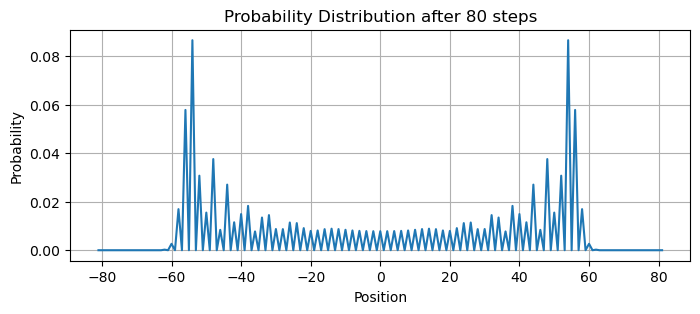

In [3]:
# Parâmetros
T = 80 # número de passos
nr = 2*T+3 # tamanho da rede
m = nr//2

# operador moeda
Ch = (1/np.sqrt(2))*np.array([
    [1, 1],
    [1, -1]
])

# Código
b = np.zeros(nr)
l_probn = np.zeros((nr,T+1))

# função para calcular o módulo quadrado da função de onda
mod = lambda a: np.sum(np.square(np.abs(a)), axis=1)

# evolução dinâmica
prob_Tn = np.zeros((nr,T+1))
a = np.zeros((nr,2), dtype=complex)
m = nr//2

#estado inicial
a[m, 0] = 1/np.sqrt(2)
a[m, 1] = 1j/np.sqrt(2)
prob_T = np.zeros((nr,T+1))
prob_T[:, 0] = mod(a)

for i in range(T):      # passos
    r = a[m-i-1:m+i+2,0]*Ch[0,0] + a[m-i-1:m+i+2, 1]*Ch[0,1]
    l = a[m-i-1:m+i+2,0]*Ch[1,0] + a[m-i-1:m+i+2, 1]*Ch[1,1]
    a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l

probability_distribution = mod(a)
positions = np.arange(-(nr//2), nr//2 + 1) # Create positions array with size nr

# Plot the results
plt.figure(figsize=(8, 3))
plt.plot(positions, probability_distribution)
plt.title(f'Probability Distribution after {T} steps')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

# DTQW with classical randomness

Classical randomness is introduced into a quantum walk (QW) by employing two rotation (coin) operators $\hat{C}_1$ and $\hat{C}_2$, instead of a single one. Their corresponding angles are defined as
$
\theta_1 = \theta_0 + \Delta\theta, \quad
\theta_2 = \theta_0 - \Delta\theta,
$
with $\theta_0 = \pi/2$.

At each step of the walk, one of the two angles is selected randomly with equal probability:
$
P(\theta = \theta_1) = P(\theta = \theta_2) = \frac{1}{2}.
$

The system evolves through the repeated application of the chosen coin operator followed by the translation operator. Although these operators are deterministic, the random selection introduces an additional probability distribution into the QW dynamics.

The coin operator is given by:
$
\hat{C}(\theta) =
\begin{pmatrix}
\cos(\theta) & i \sin(\theta) \\
i \sin(\theta) & \cos(\theta)
\end{pmatrix}.
$

After $N$ steps, the state evolves as:
$
|\psi(t)\rangle = (\hat{T}\hat{C})^N |\psi_0\rangle.
$

By varying $\Delta\theta$ in the range $0 \leq \Delta\theta \leq \theta_0$, one can explore phenomena such as the localization transition.

In [4]:
# functions

# coin
def C(theta):
    return np.array([
        [np.cos(theta), 1j*np.sin(theta)],
        [1j*np.sin(theta), np.cos(theta)]
    ])

# função para calcular o módulo quadrado da função de onda
mod = lambda a: np.sum(np.square(np.abs(a)), axis=1)


## For one

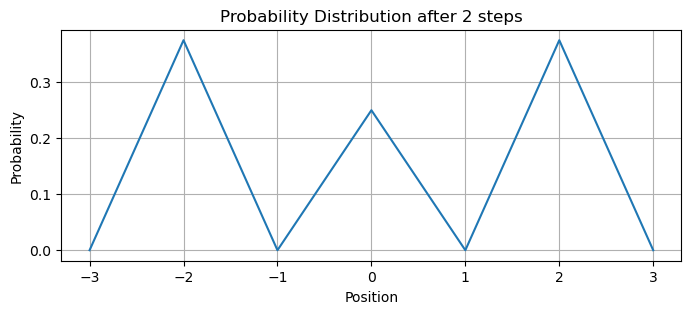

In [5]:
# Parâmetros
T = 2 # número de passos
nr = 2*T+3 # tamanho da rede
m = nr//2

# operador moeda
tt = np.pi/6

# Código
b = np.zeros(nr)
l_probn = np.zeros((nr,T+1))

# evolução dinâmica
prob_Tn = np.zeros((nr,T+1))
a = np.zeros((nr,2), dtype=complex)
m = nr//2

#estado inicial
a[m, 0] = 1/np.sqrt(2)
a[m, 1] = 1/np.sqrt(2)
prob_T = np.zeros((nr,T+1))
prob_T[:, 0] = mod(a)

for i in range(T):      # passos
    r = a[m-i-1:m+i+2,0]*C(tt)[0,0] + a[m-i-1:m+i+2, 1]*C(tt)[0,1]
    l = a[m-i-1:m+i+2,0]*C(tt)[1,0] + a[m-i-1:m+i+2, 1]*C(tt)[1,1]
    a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l

probability_distribution = mod(a)
positions = np.arange(-(nr//2), nr//2 + 1) # Create positions array with size nr

# Plot the results
plt.figure(figsize=(8, 3))
plt.plot(positions, probability_distribution)
plt.title(f'Probability Distribution after {T} steps')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

## For random choice

In [8]:
# random list
rand = lambda theta1, theta2, size: np.where(np.random.default_rng().integers(0,2,size),theta1,theta2)
rand(np.pi,-np.pi,30)

array([ 3.14159265, -3.14159265, -3.14159265,  3.14159265, -3.14159265,
       -3.14159265,  3.14159265, -3.14159265, -3.14159265,  3.14159265,
        3.14159265, -3.14159265, -3.14159265, -3.14159265, -3.14159265,
        3.14159265, -3.14159265,  3.14159265,  3.14159265, -3.14159265,
        3.14159265, -3.14159265, -3.14159265,  3.14159265,  3.14159265,
        3.14159265, -3.14159265,  3.14159265,  3.14159265, -3.14159265])

In [9]:
def DTQW_rand(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l

      return mod(a) # modulus of array

In [10]:
def DTQW_rand_amp(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l

      return a 

checking normalization

In [11]:
def DTQW_rand_check(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)
      
      sum_prob = []

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
          sum_prob.append(np.sum(mod(a)))

      return np.array(sum_prob) # sum of modulus of array

DTQW_rand_check(np.pi/4,-np.pi/4,100)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### One evolution

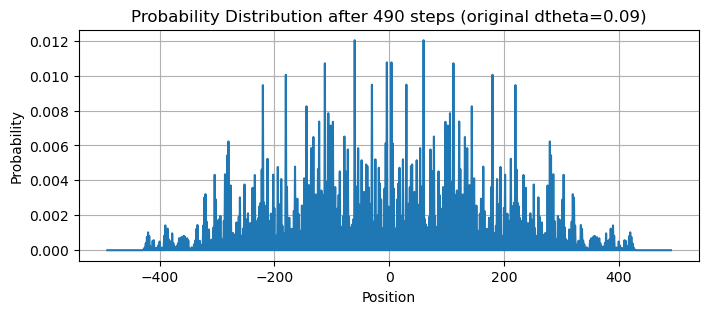

In [12]:
# Célula original: uma evolução com dtheta = 0.09 (mantida)
T = 490

theta0  = np.pi/6
dtheta = 0.09 # 0 =< dtheta =< theta0

theta1 = theta0 + dtheta
theta2 = theta0 - dtheta

#Prob = DTQW_rand(theta1,theta2,T)

Prob = DTQW_rand(theta1,theta2,T)

nr = 2*T+3

positions = np.arange(-(nr//2), nr//2 + 1) # Create positions array with size nr

# Plot the results
plt.figure(figsize=(8, 3))
plt.plot(positions, Prob)
plt.title(f'Probability Distribution after {T} steps (original dtheta=0.09)')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

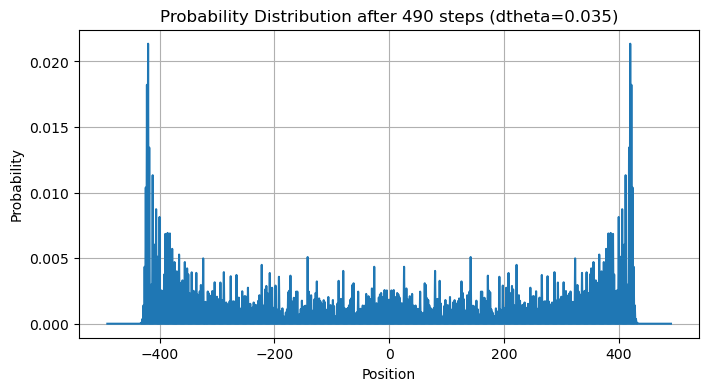

In [13]:
# Nova célula: plot único para dtheta = 0.035
T = 490
theta0 = np.pi/6
dtheta = 0.035
nr = 2*T+3
positions = np.arange(-(nr//2), nr//2 + 1)

# calcular e plotar
theta1 = theta0 + dtheta
theta2 = theta0 - dtheta
Prob = DTQW_rand(theta1, theta2, T)
plt.figure(figsize=(8,4))
plt.plot(positions, Prob)
plt.title(f'Probability Distribution after {T} steps (dtheta={dtheta})')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

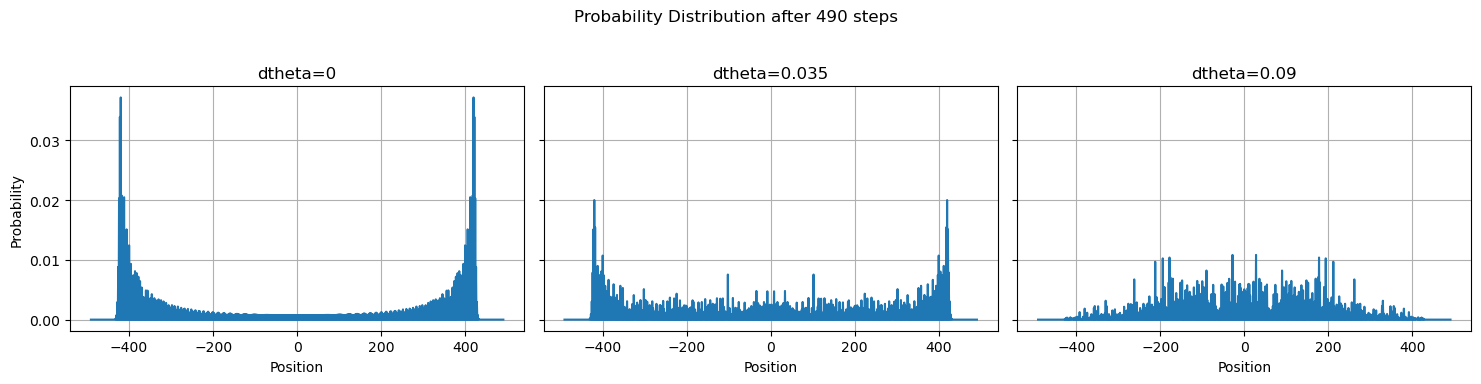

In [14]:
# Plots for three dtheta values in a single figure (side-by-side)
T = 490
theta0  = np.pi/6
dtheta_list = [0, 0.035, 0.09]  # valores solicitados
nr = 2*T+3
positions = np.arange(-(nr//2), nr//2 + 1)  # Create positions array with size nr

# create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, len(dtheta_list), figsize=(15, 4), sharey=True)
for ax, dtheta in zip(axes, dtheta_list):
    theta1 = theta0 + dtheta
    theta2 = theta0 - dtheta
    # roda uma evolução aleatória e obtém a distribuição de probabilidade
    Prob = DTQW_rand(theta1, theta2, T)
    ax.plot(positions, Prob)
    ax.set_title(f'dtheta={dtheta}')
    ax.set_xlabel('Position')
    ax.grid(True)
# shared y-label on the leftmost axis
axes[0].set_ylabel('Probability')
plt.suptitle(f'Probability Distribution after {T} steps')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [15]:
np.sum(Prob)

1.0000000000000178

### Mean of the Namos evolutions

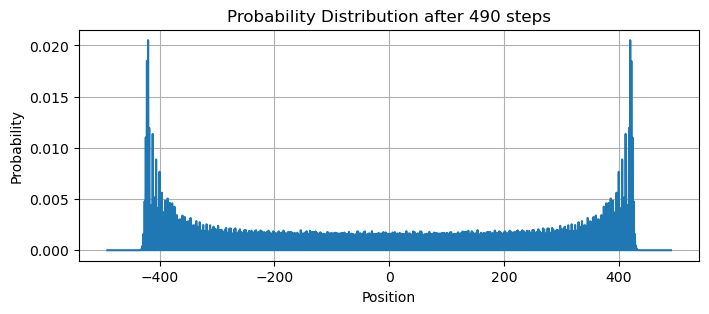

In [16]:
T = 490

theta0  = np.pi/6
dtheta = 0.035 # 0 =< dtheta =< theta0

theta1 = theta0 + dtheta
theta2 = theta0 - dtheta

#Prob = DTQW_rand(theta1,theta2,T)

Namos = 100
P = np.zeros(nr)

for i in range(Namos):
    P = P + DTQW_rand(theta1,theta2,T)

Prob = P/Namos

nr = 2*T+3

positions = np.arange(-(nr//2), nr//2 + 1) # Create positions array with size nr

# Plot the results
plt.figure(figsize=(8, 3))
plt.plot(positions, Prob)
plt.title(f'Probability Distribution after {T} steps')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

## Amplitude de probabilidade

In [17]:
# Nova célula: plot único para dtheta = 0.035
T = 490
theta0 = np.pi/6
dtheta = 0.035
nr = 2*T+3
positions = np.arange(-(nr//2), nr//2 + 1)

# calcular e plotar
theta1 = theta0 + dtheta
theta2 = theta0 - dtheta
amp = DTQW_rand_amp(theta1, theta2, T)

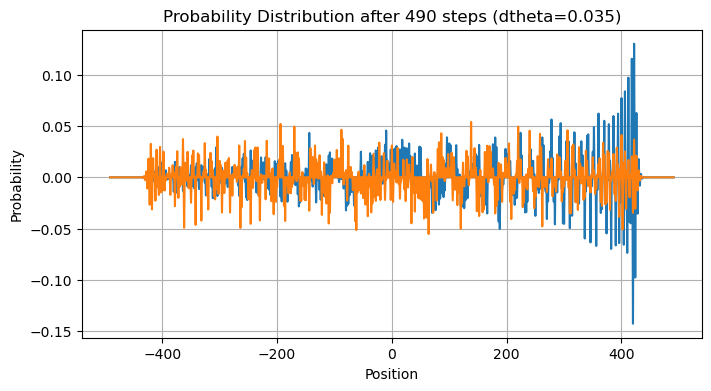

In [19]:

plt.figure(figsize=(8,4))
plt.plot(positions, amp[:][:,0].real)
plt.plot(positions, amp[:][:,0].imag)
plt.title(f'Probability Distribution after {T} steps (dtheta={dtheta})')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

In [ ]:
theta0  = np.pi/4
dtheta = np.pi/3 # 0 =< dtheta =< theta0

theta1 = theta0 + dtheta
theta2 = theta0 - dtheta

rand(theta1,theta2,100)

# IPR

Primeiramente se identifica a qual moeda está relacionada cada uma das colunas

In [21]:
# Nova célula: plot único para dtheta = 0.035
T = 490
theta0 = np.pi/6
dtheta = 0.035
nr = 2*T+3
positions = np.arange(-(nr//2), nr//2 + 1)

# calcular e plotar
theta1 = theta0 + dtheta
theta2 = theta0 - dtheta
amp = DTQW_rand_amp(theta1, theta2, T)

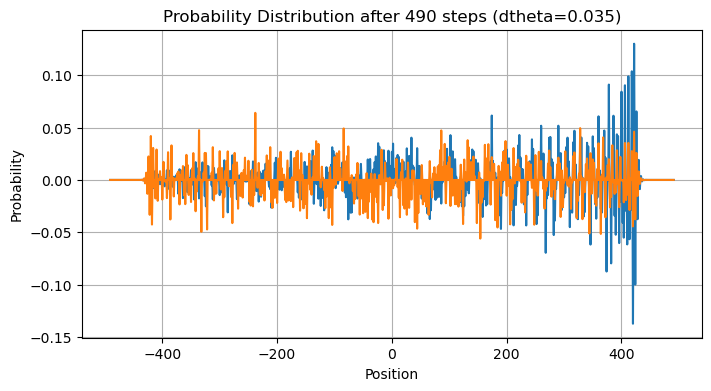

In [22]:

plt.figure(figsize=(8,4))
plt.plot(positions, amp[:][:,0].real)
plt.plot(positions, amp[:][:,0].imag)
plt.title(f'Probability Distribution after {T} steps (dtheta={dtheta})')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

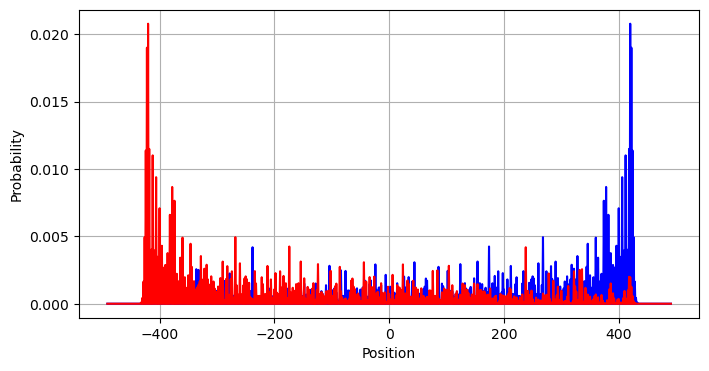

In [23]:
plus_prob = np.square(np.abs(amp[:][:,0]))
minus_prob = np.square(np.abs(amp[:][:,1]))

plt.figure(figsize=(8,4))
plt.plot(positions, plus_prob.real, color='blue', label='+')
plt.plot(positions, minus_prob.real, color='red', label='-')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

Definindo o IPR de acordo com Mastandrea e Chen (2023)

In [24]:
IPR = lambda coin_amp: (np.sum(np.square(np.abs(coin_amp)))**2)/np.sum(np.square(np.abs(coin_amp))**2)
# coin_amp: amplitude de probabilidade da partícula está em x com uma determinada moeda ( |x,+> )

In [25]:
np.square(2),np.sqrt(2),np.abs(2j)

(4, 1.4142135623730951, 2.0)

Calculando o IPR variando no tempo

In [26]:
def IPR_time(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      IPR_list = np.zeros(T+1)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
          IPR_list[i+1] = IPR(r)
      return IPR_list

In [27]:
def IPR_final_time(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      IPR_list = np.zeros(T+1)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
      return IPR(r)

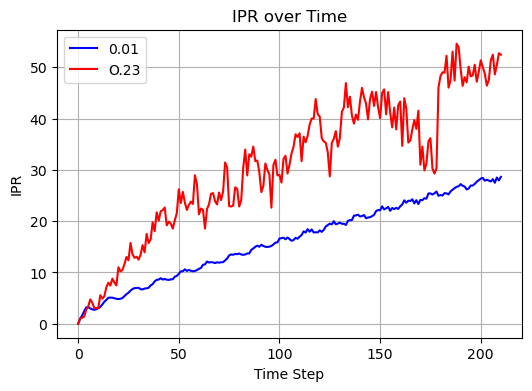

In [28]:
T = 210

theta0 = np.pi/6
dtheta = 0.01
theta1 = theta0 + dtheta
theta2 = theta0 - dtheta

dtheta2 = 0.23
theta12 = theta0 + dtheta2
theta22 = theta0 - dtheta2

IPR_values = IPR_time(theta1, theta2, T)
IPR_values2 = IPR_time(theta12, theta22, T)

plt.figure(figsize=(6,4))
plt.plot(range(T+1), IPR_values, color='blue', label='0.01')
plt.plot(range(T+1), IPR_values2, color='red', label='O.23')
plt.title('IPR over Time')
plt.xlabel('Time Step')
plt.ylabel('IPR')
plt.grid(True)
plt.legend()
plt.show()

In [29]:
def theta_list(theta0,dtheta_list):
    return [theta0 + dtheta for dtheta in dtheta_list], [theta0 - dtheta for dtheta in dtheta_list]

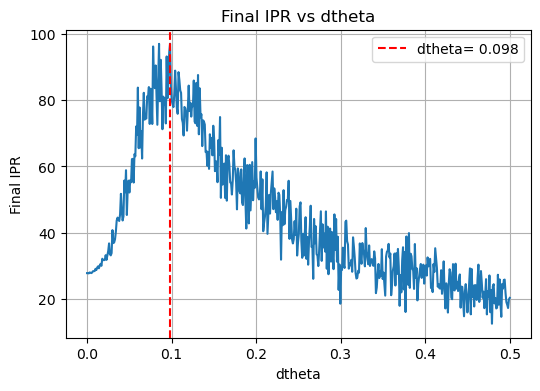

In [42]:
dtheta_list = np.linspace(0, 0.5, 500)
Theta_list = theta_list(np.pi/6,dtheta_list)

IPR_final = []
for th1, th2 in zip(Theta_list[0], Theta_list[1]):
    IPR_final.append(IPR_final_time(th1, th2, T))

plt.figure(figsize=(6,4))
plt.plot(dtheta_list, IPR_final)
plt.axvline(x=dtheta_list[np.argmax(IPR_final)], color='red', linestyle='--', label='dtheta= ' + str(np.round(dtheta_list[np.argmax(IPR_final)],3)))
plt.title('Final IPR vs dtheta')
plt.xlabel('dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

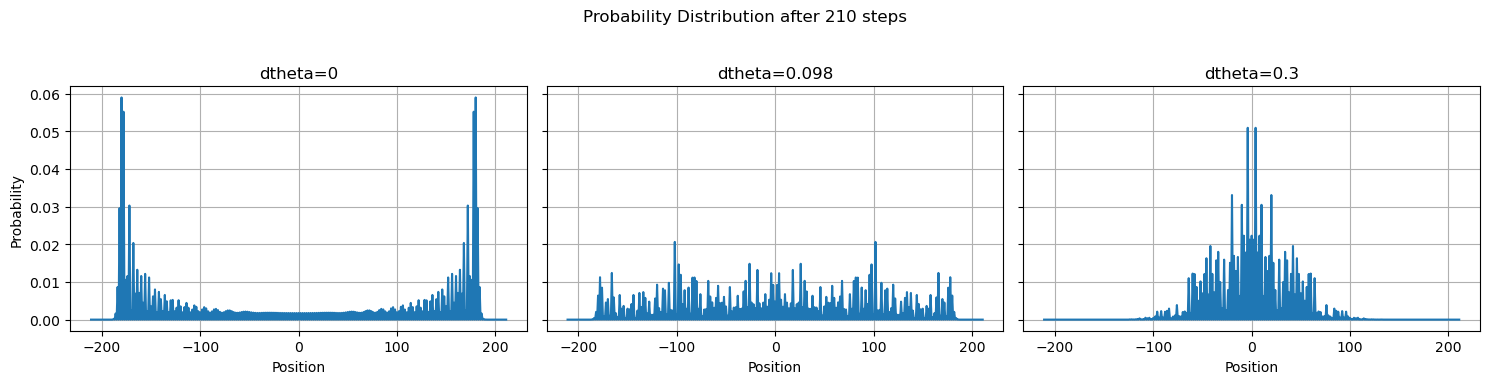

In [46]:
# Plots for three dtheta values in a single figure (side-by-side)
T = 210
theta0  = np.pi/6
dtheta_list = [0, 0.098, 0.3]  # valores solicitados
nr = 2*T+3
positions = np.arange(-(nr//2), nr//2 + 1)  # Create positions array with size nr

# create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, len(dtheta_list), figsize=(15, 4), sharey=True)
for ax, dtheta in zip(axes, dtheta_list):
    theta1 = theta0 + dtheta
    theta2 = theta0 - dtheta
    # roda uma evolução aleatória e obtém a distribuição de probabilidade
    Prob = DTQW_rand(theta1, theta2, T)
    ax.plot(positions, Prob)
    ax.set_title(f'dtheta={dtheta}')
    ax.set_xlabel('Position')
    ax.grid(True)
# shared y-label on the leftmost axis
axes[0].set_ylabel('Probability')
plt.suptitle(f'Probability Distribution after {T} steps')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

$N=490$

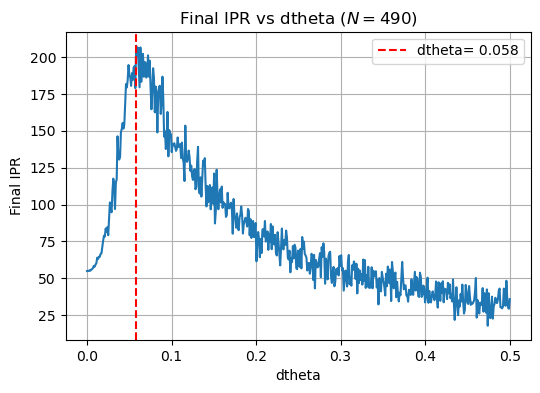

In [44]:
dtheta_list = np.linspace(0, 0.5, 500)
Theta_list = theta_list(np.pi/6,dtheta_list)

IPR_final = []
for th1, th2 in zip(Theta_list[0], Theta_list[1]):
    IPR_final.append(IPR_final_time(th1, th2, 490))

plt.figure(figsize=(6,4))
plt.plot(dtheta_list, IPR_final)
plt.axvline(x=dtheta_list[np.argmax(IPR_final)], color='red', linestyle='--', label='dtheta= ' + str(np.round(dtheta_list[np.argmax(IPR_final)],3)))
plt.title(r'Final IPR vs dtheta ($N=490$)')
plt.xlabel('dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

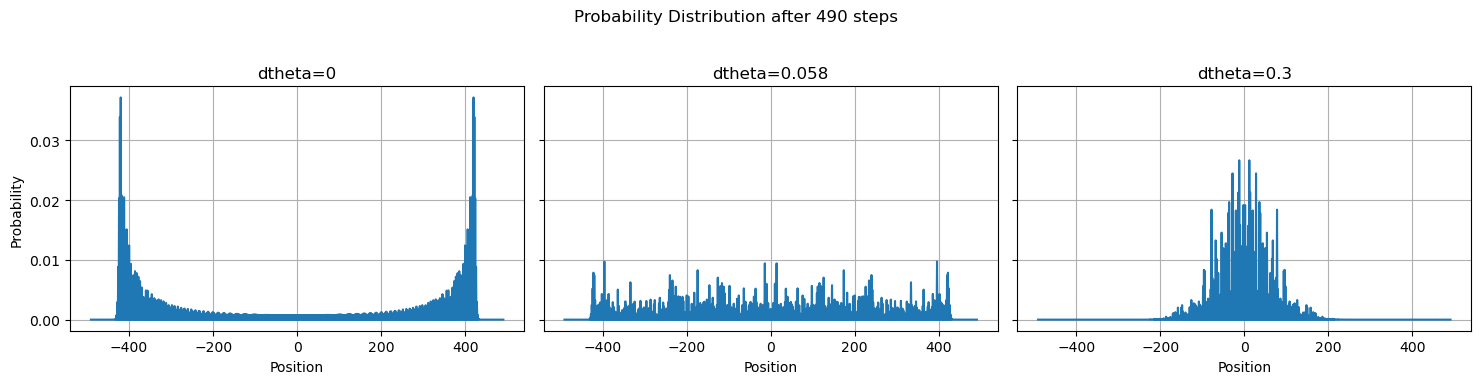

In [47]:
# Plots for three dtheta values in a single figure (side-by-side)
T = 490
theta0  = np.pi/6
dtheta_list = [0, 0.058, 0.3]  # valores solicitados
nr = 2*T+3
positions = np.arange(-(nr//2), nr//2 + 1)  # Create positions array with size nr

# create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, len(dtheta_list), figsize=(15, 4), sharey=True)
for ax, dtheta in zip(axes, dtheta_list):
    theta1 = theta0 + dtheta
    theta2 = theta0 - dtheta
    # roda uma evolução aleatória e obtém a distribuição de probabilidade
    Prob = DTQW_rand(theta1, theta2, T)
    ax.plot(positions, Prob)
    ax.set_title(f'dtheta={dtheta}')
    ax.set_xlabel('Position')
    ax.grid(True)
# shared y-label on the leftmost axis
axes[0].set_ylabel('Probability')
plt.suptitle(f'Probability Distribution after {T} steps')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Mol

In [33]:
def Mol(Prob):
    positions = np.arange(-(len(Prob)//2), len(Prob)//2 + 1)
    return np.sum((positions**2) * Prob)

In [34]:
def Mol_time(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      Mol_list = np.zeros(T+1)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
          Mol_list[i+1] = Mol(mod(a))
      return Mol_list 

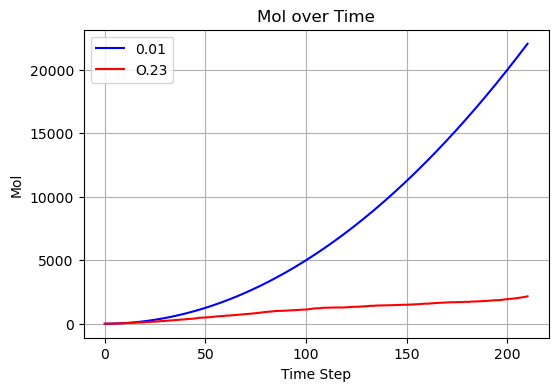

In [35]:
T = 210

theta0 = np.pi/6
dtheta = 0.001
theta1 = theta0 + dtheta
theta2 = theta0 - dtheta

dtheta2 = 0.24
theta12 = theta0 + dtheta2
theta22 = theta0 - dtheta2

Mol_values = Mol_time(theta1, theta2, T)
Mol_values2 = Mol_time(theta12, theta22, T)

plt.figure(figsize=(6,4))
plt.plot(range(T+1), Mol_values, color='blue', label='0.01')
plt.plot(range(T+1), Mol_values2, color='red', label='O.23')
plt.title('Mol over Time')
plt.xlabel('Time Step')
plt.ylabel('Mol')
plt.grid(True)
plt.legend()
plt.show()

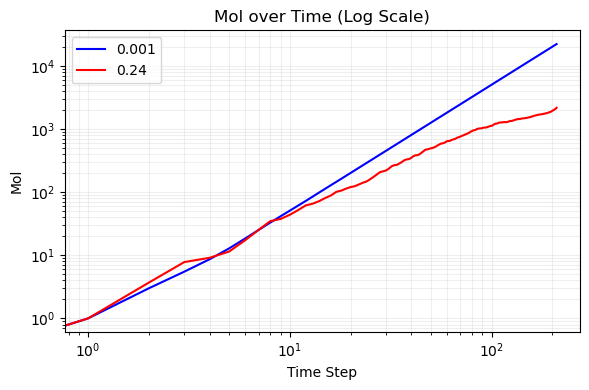

In [36]:
plt.figure(figsize=(6, 4))

# Plotagem
plt.plot(range(T+1), Mol_values, color='blue', label='0.001')
plt.plot(range(T+1), Mol_values2, color='red', label='0.24')

# --- ESCALA LOGARÍTMICA ---
plt.yscale('log') 
plt.xscale('log')
# Se quiser o eixo X em log também, descomente a linha abaixo:
# plt.xscale('log') 

plt.title('Mol over Time (Log Scale)')
plt.xlabel('Time Step')
plt.ylabel('Mol')
plt.grid(True, which="both", ls="-", alpha=0.2) # Grade adaptada para log
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
def Mol_final_time(theta1,theta2,T):

      nr = 2*T+3 # tamanho da rede
      m = nr//2
      a = np.zeros((nr,2), dtype=complex)
      #estado inicial
      a[m, 0] = 1/np.sqrt(2)
      a[m, 1] = 1/np.sqrt(2)
      prob_T = np.zeros((nr,T+1))
      prob_T[:, 0] = mod(a)

      # random theta list
      ttr = rand(theta1,theta2,T)

      # walking
      for i in range(T):      # passos
          Cr = C(ttr[i])
          r = a[m-i-1:m+i+2,0]*Cr[0,0] + a[m-i-1:m+i+2, 1]*Cr[0,1]
          l = a[m-i-1:m+i+2,0]*Cr[1,0] + a[m-i-1:m+i+2, 1]*Cr[1,1]
          a[m-i:m+i+3, 0], a[m-i-2:m+i+1, 1] = r, l
      return Mol(mod(a))

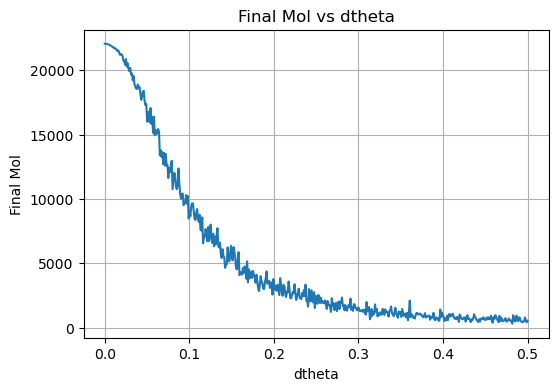

In [38]:
dtheta_list = np.linspace(0, 0.5, 500)
Theta_list = theta_list(np.pi/6,dtheta_list)

Mol_final = []
for th1, th2 in zip(Theta_list[0], Theta_list[1]):
    Mol_final.append(Mol_final_time(th1, th2, T))

plt.figure(figsize=(6,4))
plt.plot(dtheta_list, Mol_final)
plt.title('Final Mol vs dtheta')
plt.xlabel('dtheta')
plt.ylabel('Final Mol')
plt.grid(True)
plt.show()

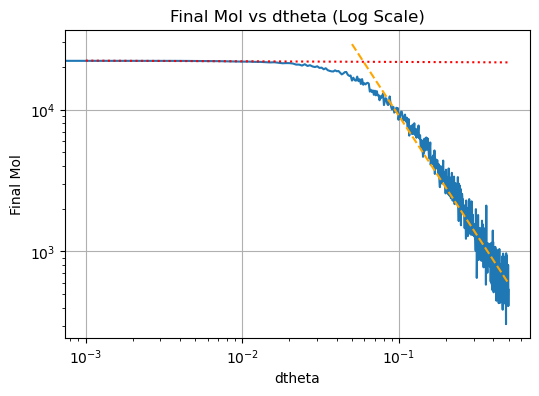

In [40]:
# 2. Regressão Linear na BASE 10
# Usamos np.log10 para m*log10(x) + log10(b)
m1, b_log101 = np.polyfit(np.log10(dtheta_list[1:10]), np.log10(Mol_final[1:10]), 1)

# 3. y_fit (Revertendo: y = 10^(b_log10) * x^m)
# Importante: a base aqui DEVE ser 10.0
y_fit1 = (10**b_log101) * (dtheta_list[1:]**m1)

m2, b_log102 = np.polyfit(np.log10(dtheta_list[-450:]), np.log10(Mol_final[-450:]), 1)
y_fit2 = (10**b_log102) * (dtheta_list[-450:]**m2)

# plot log scale
plt.figure(figsize=(6,4))

plt.plot(dtheta_list, Mol_final)
plt.plot(dtheta_list[1:], y_fit1, ':', color='red', label=f'Ajuste Log-Log (Base 10)')
plt.plot(dtheta_list[-450:], y_fit2, '--', color='orange', label=f'Ajuste Log-Log (Base 10)')

plt.yscale('log')
plt.xscale('log')
plt.title('Final Mol vs dtheta (Log Scale)')
plt.xlabel('dtheta')
plt.ylabel('Final Mol')
plt.grid(True)
plt.show()